In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load the same dataset from Day 1
df = pd.read_parquet('../data/DDoS-Friday-no-metadata.parquet')

# Confirm it loaded correctly
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nLabel counts:")
print(df['Label'].value_counts())

Dataset loaded: 221,264 rows, 78 columns

Label counts:
Label
DDoS      128014
Benign     93250
Name: count, dtype: int64


In [2]:
# Check missing values column by column
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print("No missing values found — dataset is clean")
else:
    print(f"Columns with missing values:")
    print(missing_cols)

# Check for infinite values
numeric_cols = df.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_cols).sum().sum()
print(f"\nInfinite values: {inf_count}")

# Check for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes:,}")

No missing values found — dataset is clean

Infinite values: 0
Duplicate rows: 0


In [3]:
original_count = len(df)

# Remove any duplicate rows
df = df.drop_duplicates()

removed = original_count - len(df)
print(f"Rows before: {original_count:,}")
print(f"Rows removed: {removed:,}")
print(f"Rows after:  {len(df):,}")

Rows before: 221,264
Rows removed: 0
Rows after:  221,264


In [4]:
from sklearn.preprocessing import LabelEncoder

# Right now Label column contains text: 'Benign' and 'DDoS'
# ML models need numbers, not text
# LabelEncoder converts: Benign → 0, DDoS → 1
le = LabelEncoder()

y = le.fit_transform(df['Label'])

print("Label encoding complete:")
for label, number in zip(le.classes_, le.transform(le.classes_)):
    print(f"  '{label}' → {number}")

print(f"\nTotal labels encoded: {len(y):,}")
print(f"Unique values in y: {np.unique(y)}")

Label encoding complete:
  'Benign' → 0
  'DDoS' → 1

Total labels encoded: 221,264
Unique values in y: [0 1]


In [5]:
# X = everything the model uses to make predictions (all columns except Label)
# y = what you are predicting (the Label column, now encoded as 0/1)

X = df.drop('Label', axis=1)

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape:   {y.shape}")
print(f"\nFeature columns ({len(X.columns)} total):")
print(list(X.columns))

Features (X) shape: (221264, 77)
Labels (y) shape:   (221264,)

Feature columns (77 total):
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag

In [6]:
from sklearn.preprocessing import StandardScaler

# Features have very different ranges:
# 'Flow Duration' might be in the millions
# 'Total Fwd Packets' might be in the tens
# Without scaling, large numbers dominate and the model learns badly
# StandardScaler brings everything to the same range (mean=0, std=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete")
print(f"Before scaling — 'Flow Duration' sample values:")
print(f"  Min: {X['Flow Duration'].min():,.0f}")
print(f"  Max: {X['Flow Duration'].max():,.0f}")
print(f"  Mean: {X['Flow Duration'].mean():,.0f}")

print(f"\nAfter scaling — 'Flow Duration' sample values:")
print(f"  Min: {X_scaled[:, 0].min():.4f}")
print(f"  Max: {X_scaled[:, 0].max():.4f}")
print(f"  Mean: {X_scaled[:, 0].mean():.4f}")

Scaling complete
Before scaling — 'Flow Duration' sample values:
  Min: -1
  Max: 119,999,937
  Mean: 16,570,471

After scaling — 'Flow Duration' sample values:
  Min: -1.9732
  Max: 2.4746
  Mean: 0.0000


In [7]:
from sklearn.model_selection import train_test_split

# 80% of data goes to training — the model learns from this
# 20% goes to testing — completely unseen data used to evaluate the model
# stratify=y ensures both splits have the same ratio of Benign/DDoS
# random_state=42 makes the split reproducible every time you run it

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/test split complete:")
print(f"  Training samples:  {len(X_train):,} ({len(X_train)/len(y)*100:.0f}%)")
print(f"  Testing samples:   {len(X_test):,} ({len(X_test)/len(y)*100:.0f}%)")

# Verify class balance is maintained in both splits
train_benign = (y_train == 0).sum()
train_ddos = (y_train == 1).sum()
test_benign = (y_test == 0).sum()
test_ddos = (y_test == 1).sum()

print(f"\nTraining set breakdown:")
print(f"  Benign: {train_benign:,} | DDoS: {train_ddos:,}")
print(f"\nTesting set breakdown:")
print(f"  Benign: {test_benign:,} | DDoS: {test_ddos:,}")

Train/test split complete:
  Training samples:  177,011 (80%)
  Testing samples:   44,253 (20%)

Training set breakdown:
  Benign: 74,600 | DDoS: 102,411

Testing set breakdown:
  Benign: 18,650 | DDoS: 25,603


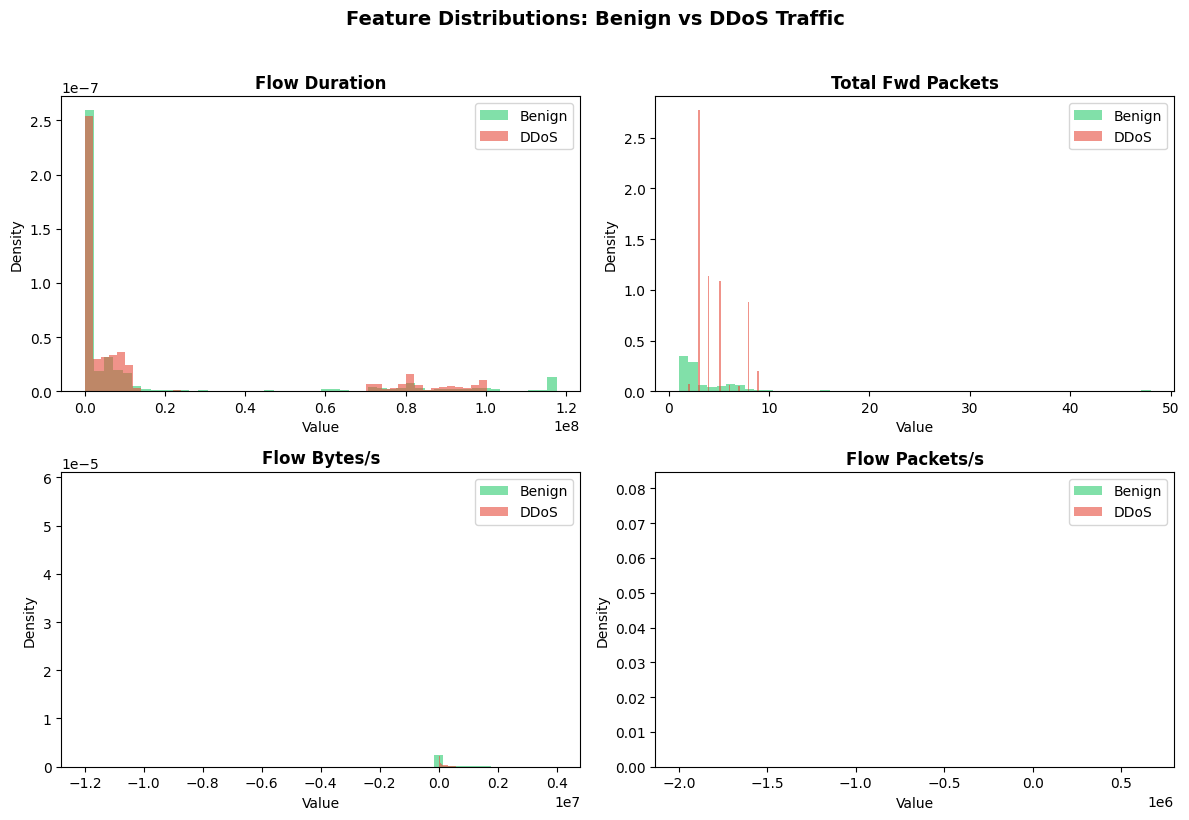

Chart saved to outputs/02-feature-distributions.png


In [8]:
# Pick 4 important features and show how their distributions
# differ between Benign and DDoS traffic
# This visually confirms the model has signal to learn from

features_to_plot = [
    'Flow Duration',
    'Total Fwd Packets', 
    'Flow Bytes/s',
    'Flow Packets/s'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Re-use original unscaled data for readable axis labels
benign_df = df[df['Label'] == 'Benign']
ddos_df = df[df['Label'] == 'DDoS']

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    # Plot distributions — clip extreme outliers for readability
    benign_vals = benign_df[feature].clip(
        upper=benign_df[feature].quantile(0.99))
    ddos_vals = ddos_df[feature].clip(
        upper=ddos_df[feature].quantile(0.99))
    
    ax.hist(benign_vals, bins=50, alpha=0.6, color='#2ecc71',
            label='Benign', density=True)
    ax.hist(ddos_vals, bins=50, alpha=0.6, color='#e74c3c',
            label='DDoS', density=True)
    
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions: Benign vs DDoS Traffic',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02-feature-distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/02-feature-distributions.png")

In [9]:
# Save all preprocessed data so Day 3 can load it instantly
# without repeating all this work

# Save the train/test splits, encoder, scaler, and feature names
with open('../models/preprocessed_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'label_encoder': le,
        'scaler': scaler,
        'feature_names': list(X.columns)
    }, f)

print("Preprocessed data saved to models/preprocessed_data.pkl")

# Confirm the file was created
import os
file_size = os.path.getsize('../models/preprocessed_data.pkl')
print(f"File size: {file_size / (1024*1024):.1f} MB")

print("\nDay 2 complete. Ready for model training tomorrow.")
print(f"Training set: {len(X_train):,} samples")
print(f"Testing set:  {len(X_test):,} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"Labels:       {le.classes_}")

Preprocessed data saved to models/preprocessed_data.pkl
File size: 131.7 MB

Day 2 complete. Ready for model training tomorrow.
Training set: 177,011 samples
Testing set:  44,253 samples
Features:     77
Labels:       ['Benign' 'DDoS']
